In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

/home/corpadm/LangGraph_projects/venv/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
load_dotenv()
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [5]:
def generate_joke(state: JokeState):
    prompt= f"generate a joke about {state['topic']}"
    response = llm.invoke(prompt).content
    return{"joke": response}
def generate_explanation(state: JokeState):
    prompt = f"explain the joke: {state['joke']}"
    response = llm.invoke(prompt).content
    return {"explanation": response}

In [6]:
graph =  StateGraph(JokeState)
graph.add_node("generate_joke",generate_joke)
graph.add_node("generate_explanation",generate_explanation)
graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge("generate_explanation", END)
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

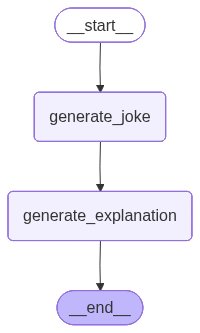

In [7]:
workflow

When we use thread_id

Use it when:

building chatbots
using memory/checkpointer
multi-step workflows
human-in-the-loop systems

In [17]:
config1 = {"configurable": {"thread_id": "1"}}#LangGraph uses thread_id to:save memory/checkpoints, continue the same conversation flow, restore previous state after interruption
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explanation': 'A classic play on words. The joke is funny because it uses a pun to create a unexpected connection between the setup and the punchline.\n\nIn this case, the setup asks why the pizza is in a bad mood, and the listener expects a typical reason, such as "it was having a bad day" or "it was upset about something." However, the punchline subverts this expectation by using the word "crusty" in a way that\'s both literal and figurative.\n\n"Crusty" has a double meaning here:\n\n1. A pizza has a crust, which is the outer layer of the bread. So, in a literal sense, a pizza can be said to be "crusty" because it has a crust.\n2. "Crusty" can also mean being irritable, gruff, or in a bad mood. For example, "He\'s been feeling crusty all day, so let\'s give him some space."\n\nThe joke relies on this wordplay to create humor. By using "crusty" to describe the pizza\'s mood, th

In [18]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A classic play on words. The joke is funny because it uses a pun to create a unexpected connection between the setup and the punchline.\n\nIn this case, the setup asks why the pizza is in a bad mood, and the listener expects a typical reason, such as "it was having a bad day" or "it was upset about something." However, the punchline subverts this expectation by using the word "crusty" in a way that\'s both literal and figurative.\n\n"Crusty" has a double meaning here:\n\n1. A pizza has a crust, which is the outer layer of the bread. So, in a literal sense, a pizza can be said to be "crusty" because it has a crust.\n2. "Crusty" can also mean being irritable, gruff, or in a bad mood. For example, "He\'s been feeling crusty all day, so let\'s give him some space."\n\nThe joke relies on this wordplay to create humor. By using "crusty" to describe th

In [19]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A classic play on words. The joke is funny because it uses a pun to create a unexpected connection between the setup and the punchline.\n\nIn this case, the setup asks why the pizza is in a bad mood, and the listener expects a typical reason, such as "it was having a bad day" or "it was upset about something." However, the punchline subverts this expectation by using the word "crusty" in a way that\'s both literal and figurative.\n\n"Crusty" has a double meaning here:\n\n1. A pizza has a crust, which is the outer layer of the bread. So, in a literal sense, a pizza can be said to be "crusty" because it has a crust.\n2. "Crusty" can also mean being irritable, gruff, or in a bad mood. For example, "He\'s been feeling crusty all day, so let\'s give him some space."\n\nThe joke relies on this wordplay to create humor. By using "crusty" to describe t

In [20]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.',
 'explanation': 'A clever play on words. The joke is funny because it uses a common phrase "tangled up in a relationship" (meaning complicated or messy) and gives it a literal twist. Spaghetti is a type of long, thin, twisted pasta, so "tangled up" has a double meaning here:\n\n1. Emotionally complicated (the usual meaning of the phrase)\n2. Physically tangled (like the spaghetti itself)\n\nThe punchline is humorous because it takes the usual concern about relationships being complicated and applies it to a food item (spaghetti) that is literally prone to tangling. It\'s a lighthearted and creative way to make a joke about relationships, using wordplay to create a clever and amusing connection.'}

In [21]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'explanation': 'A clever play on words. The joke is funny because it uses a common phrase "tangled up in a relationship" (meaning complicated or messy) and gives it a literal twist. Spaghetti is a type of long, thin, twisted pasta, so "tangled up" has a double meaning here:\n\n1. Emotionally complicated (the usual meaning of the phrase)\n2. Physically tangled (like the spaghetti itself)\n\nThe punchline is humorous because it takes the usual concern about relationships being complicated and applies it to a food item (spaghetti) that is literally prone to tangling. It\'s a lighthearted and creative way to make a joke about relationships, using wordplay to create a clever and amusing connection.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1581fb-bc40-6332-8006-e326440ab364'}}, 

In [22]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'explanation': 'A clever play on words. The joke is funny because it uses a common phrase "tangled up in a relationship" (meaning complicated or messy) and gives it a literal twist. Spaghetti is a type of long, thin, twisted pasta, so "tangled up" has a double meaning here:\n\n1. Emotionally complicated (the usual meaning of the phrase)\n2. Physically tangled (like the spaghetti itself)\n\nThe punchline is humorous because it takes the usual concern about relationships being complicated and applies it to a food item (spaghetti) that is literally prone to tangling. It\'s a lighthearted and creative way to make a joke about relationships, using wordplay to create a clever and amusing connection.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1581fb-bc40-6332-8006-e326440ab364'}},

### Time Travel

In [27]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1581f2-f09f-64c3-8000-30e7f209f82e"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1581f2-f09f-64c3-8000-30e7f209f82e'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-25T09:50:38.160807+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1581f2-f09d-6cbc-bfff-ee81c82e6771'}}, tasks=(PregelTask(id='fe35b22a-ff91-902b-f7fd-ed83ab3f3be4', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.'}),), interrupts=())

In [ ]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1581f2-f09f-64c3-8000-30e7f209f82e"}})
"""Why this is used

This is used to:

Resume/replay execution from an existing checkpoint.

LangGraph loads the saved state from that checkpoint and continues execution."""

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explanation': 'A classic play on words. The joke is funny because it uses a pun to create a wordplay. \n\nIn this joke, "crusty" has a double meaning:\n1. A pizza has a crust, which is the outer layer of the pizza. So, in this context, "crusty" refers to the physical property of the pizza.\n2. "Crusty" can also mean being irritable, grumpy, or having a bad temper. For example, "He\'s a crusty old man" means he\'s a bit gruff or short-tempered.\n\nThe joke relies on this dual meaning of "crusty" to create humor. It sets up the expectation that the pizza is in a bad mood, and then subverts it by using the word "crusty" in a way that\'s both literal (the pizza has a crust) and figurative (the pizza is feeling grumpy). The unexpected twist creates the comedic effect.'}

In [28]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'A classic play on words. The joke is funny because it uses a pun to create a wordplay. \n\nIn this joke, "crusty" has a double meaning:\n1. A pizza has a crust, which is the outer layer of the pizza. So, in this context, "crusty" refers to the physical property of the pizza.\n2. "Crusty" can also mean being irritable, grumpy, or having a bad temper. For example, "He\'s a crusty old man" means he\'s a bit gruff or short-tempered.\n\nThe joke relies on this dual meaning of "crusty" to create humor. It sets up the expectation that the pizza is in a bad mood, and then subverts it by using the word "crusty" in a way that\'s both literal (the pizza has a crust) and figurative (the pizza is feeling grumpy). The unexpected twist creates the comedic effect.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1

### Updating State

What is checkpoint_ns in LangGraph?

checkpoint_ns = checkpoint namespace
It is used to separate different groups of checkpoints inside the same thread_id.
Think of it like:
thread_id = User
checkpoint_ns = Folder
checkpoint_id = Specific save file

Why LangGraph needs it
A single thread can contain:

main graph checkpoints
subgraph checkpoints
agent checkpoints
tool checkpoints
parallel branch checkpoints

Without namespaces, all checkpoints would mix together.

In [32]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1581f2-f2c7-6bbd-8001-6b49435592b7","checkpoint_ns": ""}}, {"topic": "sushi"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f158226-24f3-60bd-8002-bda6760a5939'}}

In [33]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'sushi', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f158226-24f3-60bd-8002-bda6760a5939'}}, metadata={'source': 'update', 'step': 2, 'parents': {}}, created_at='2026-05-25T10:13:32.668524+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1581f2-f2c7-6bbd-8001-6b49435592b7'}}, tasks=(PregelTask(id='51e3f6ae-cca2-93d2-d97f-7165a45b4cee', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'sushi'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f158223-3013-642e-8001-25981851b8f9'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-25T10:

In [36]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f158223-3013-642e-8001-25981851b8f9"}})

{'topic': 'sushi',
 'joke': 'Why did the sushi go to therapy?\n\nBecause it was feeling a little "raw" and wanted to work through some "roll"-ing emotions.',
 'explanation': 'A clever play on words. The joke relies on a pun to create the humorous effect. Here\'s a breakdown:\n\n1. **"Raw"**: Sushi often contains raw fish, so the word "raw" has a literal meaning in this context. However, "feeling raw" is also an idiomatic expression that means feeling vulnerable, sensitive, or emotionally exposed. The joke exploits this double meaning to create a connection between the sushi\'s emotional state and its physical composition.\n2. **"Roll"-ing emotions**: This is another pun. Sushi is often served in roll form (e.g., maki rolls), so the word "roll" has a literal connection to the food. However, "rolling emotions" is a phrase that means emotions that are intense, overwhelming, or constantly changing. The joke uses this phrase to create a wordplay between the physical act of rolling sushi and

In [37]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'sushi', 'joke': 'Why did the sushi go to therapy?\n\nBecause it was feeling a little "raw" and wanted to work through some "roll"-ing emotions.', 'explanation': 'A clever play on words. The joke relies on a pun to create the humorous effect. Here\'s a breakdown:\n\n1. **"Raw"**: Sushi often contains raw fish, so the word "raw" has a literal meaning in this context. However, "feeling raw" is also an idiomatic expression that means feeling vulnerable, sensitive, or emotionally exposed. The joke exploits this double meaning to create a connection between the sushi\'s emotional state and its physical composition.\n2. **"Roll"-ing emotions**: This is another pun. Sushi is often served in roll form (e.g., maki rolls), so the word "roll" has a literal connection to the food. However, "rolling emotions" is a phrase that means emotions that are intense, overwhelming, or constantly changing. The joke uses this phrase to create a wordplay between the physical act 

### Fault Tolerance
Fault tolerance means:

A system can continue working even if some parts fail.

In [38]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [39]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [46]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(10)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [47]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

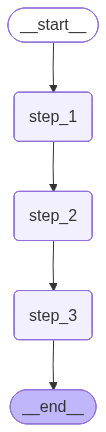

In [48]:
graph

In [49]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [50]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}


In [51]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f158248-6557-6151-8003-62ab8cff84df'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-25T10:28:52.100928+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f158248-6554-618d-8002-1e389f9871b3'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f158248-6554-618d-8002-1e389f9871b3'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-25T10:28:52.099671+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f158247-c20c-69dd-8001-21c17b79ddcf'}}, tasks=(PregelTask(id='16fda3c2-3f62-fcf3-4e43-1941ca8d586